**Import Needed Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Data using Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
base_path = '/content/drive/MyDrive/Jobaaj Projects/Python-SQL Project/'

In [4]:
df_customers = pd.read_csv(base_path + 'customers.csv', encoding='latin1')
df_geolocation = pd.read_csv(base_path + 'geolocation.csv', encoding='latin1')
df_order_items = pd.read_csv(base_path + 'order_items.csv', encoding='latin1')
df_orders = pd.read_csv(base_path + 'orders.csv', encoding='latin1')
df_payments = pd.read_csv(base_path + 'payments.csv', encoding='latin1')
df_products = pd.read_csv(base_path + 'products.csv', encoding='latin1')
df_sellers = pd.read_csv(base_path + 'sellers.csv', encoding='latin1')

**EDA**

In [ ]:
display(df_customers.head(5))
display(df_geolocation.head(5))
display(df_order_items.head(5))
display(df_orders.head(5))
display(df_payments.head(5))
display(df_products.head(5))
display(df_sellers.head(5))

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 9:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 3:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 0:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 8:38:49,2018-08-08 8:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 0:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 0:28:42,2017-12-15 0:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 0:00:00


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


,product_id,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sport leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,babies,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Checking Shapes and Describe of all TABLES and Null Values**

In [ ]:
print("SHAPE: ", df_customers.shape)
print("Table Info: ", "\n",df_customers.describe(include='all'))

print("Missing Values Data: ", "\n", df_customers.isnull().sum())

SHAPE:  (99441, 5)
Table Info:  
                              customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     274fa6071e5e17fe303b9748641082c8  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_pre

In [ ]:
print ("SHAPE: ", df_geolocation.shape)
print("Table Info: ", "\n",df_geolocation.describe(include='all'))

print("Missing Values Data: ", "\n", df_geolocation.isnull().sum())

SHAPE:  (1000163, 5)
Missing Values Data:  
 geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [ ]:
print ("SHAPE: ", df_orders.shape)
print("Table Info: ", "\n",df_orders.describe(include='all'))

print("Missing Values Data: ", "\n", df_orders.isnull().sum())

SHAPE:  (99441, 8)
Table Info:  
                                 order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   
freq                                   1                                 1   

       order_status order_purchase_timestamp   order_approved_at  \
count         99441                    99441               99281   
unique            8                    98875               90733   
top       delivered      2018-08-02 12:06:07  2018-02-27 4:31:10   
freq          96478                        3                   9   

       order_delivered_carrier_date order_delivered_customer_date  \
count                         97658                         96476   
unique                        81018                         95664   
top             2018-05-09 

In [ ]:
print ("SHAPE: ", df_payments.shape)
print("Table Info: ", "\n",df_payments.describe(include='all'))

print("Missing Values Data: ", "\n", df_payments.isnull().sum())

SHAPE:  (103886, 5)
Table Info:  
                                 order_id  payment_sequential payment_type  \
count                             103886       103886.000000       103886   
unique                             99440                 NaN            5   
top     fa65dad1b0e818e3ccc5cb0e39231352                 NaN  credit_card   
freq                                  29                 NaN        76795   
mean                                 NaN            1.092679          NaN   
std                                  NaN            0.706584          NaN   
min                                  NaN            1.000000          NaN   
25%                                  NaN            1.000000          NaN   
50%                                  NaN            1.000000          NaN   
75%                                  NaN            1.000000          NaN   
max                                  NaN           29.000000          NaN   

        payment_installments  payment_va

In [ ]:
print("SHAPE: ", df_products.shape)
print("Table Info: ", "\n",df_products.describe(include='all'))

print("Missing Values Data: ", "\n", df_products.isnull().sum())

SHAPE:  (32951, 9)
Table Info:  
                               product_id product category  \
count                              32951            32341   
unique                             32951               73   
top     106392145fca363410d287a815be6de4   bed table bath   
freq                                   1             3029   
mean                                 NaN              NaN   
std                                  NaN              NaN   
min                                  NaN              NaN   
25%                                  NaN              NaN   
50%                                  NaN              NaN   
75%                                  NaN              NaN   
max                                  NaN              NaN   

        product_name_length  product_description_length  product_photos_qty  \
count          32341.000000                32341.000000        32341.000000   
unique                  NaN                         NaN                 NaN

In [ ]:
print ("SHAPE: ", df_sellers.shape)
print("Table Info: ", "\n",df_sellers.describe(include='all'))

print("Missing Values Data: ", "\n", df_sellers.isnull().sum())

SHAPE:  (3095, 4)
Table Info:  
                                seller_id  seller_zip_code_prefix seller_city  \
count                               3095             3095.000000        3095   
unique                              3095                     NaN         611   
top     9e25199f6ef7e7c347120ff175652c3b                     NaN   sao paulo   
freq                                   1                     NaN         694   
mean                                 NaN            32291.059451         NaN   
std                                  NaN            32713.453830         NaN   
min                                  NaN             1001.000000         NaN   
25%                                  NaN             7093.500000         NaN   
50%                                  NaN            14940.000000         NaN   
75%                                  NaN            64552.500000         NaN   
max                                  NaN            99730.000000         NaN   

      

**Merging all the DataFrame to make a single DataFrame for Analysis**

In [5]:
# Start with orders and merge customers
df_order_customer = pd.merge(df_orders, df_customers, on='customer_id', how='left')

# Merge order items
df_customer_items = pd.merge(df_order_customer, df_order_items, on='order_id', how='left')

# Merge payments
df_customer_payments = pd.merge(df_customer_items, df_payments, on='order_id', how='left')

# Merge products
df_customer_product = pd.merge(df_customer_payments, df_products, on='product_id', how='left')

# Merge sellers
df_merged = pd.merge(df_customer_product, df_sellers, on='seller_id', how='left')


print("Shape of the merged DataFrame:", df_merged.shape)
display(df_merged.head())

Shape of the merged DataFrame: (118434, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 3:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 0:00:00,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 8:38:49,2018-08-08 8:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 0:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP


In [ ]:
print("Missing data in the merged DataFrame:")
print(df_merged.isnull().sum())

Missing data in the merged DataFrame:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
product category                 2528
product_name_length              2528
product_description_length       2528
product_phot

In [11]:
df_merged = df_merged.rename(columns={'product category': 'product_category'})

In [ ]:
print("Data types:\n", df_merged.dtypes)

Data types:
 order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
product_category                  object
product_name_length              float64
pro

**Changing DataType for Data Columns**

In [ ]:
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])
df_merged['order_approved_at'] = pd.to_datetime(df_merged['order_approved_at'])
df_merged['order_delivered_carrier_date'] = pd.to_datetime(df_merged['order_delivered_carrier_date'])
df_merged['order_delivered_customer_date'] = pd.to_datetime(df_merged['order_delivered_customer_date'])
df_merged['order_estimated_delivery_date'] = pd.to_datetime(df_merged['order_estimated_delivery_date'])
df_merged['shipping_limit_date'] = pd.to_datetime(df_merged['shipping_limit_date'])

In [ ]:
print("Data types:\n", df_merged.dtypes)

Data types:
 order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
order_item_id                           float64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
payment_sequential                      float64
payment_type                             object
payment_installments       

**Handling Missing Data**

Fill Null Value in category With "Unknown"

In [ ]:
df_merged['product_category'].fillna('unknown', inplace=True)

/tmp/ipython-input-1630505087.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['product_category'].fillna('unknown', inplace=True)


In [ ]:
df_merged.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


# **1. BASIC PROBLEMS**

### A. List all unique cities where customers are located.

In [ ]:
Unique_customer_city = sorted(df_customers['customer_city'].unique())
print("Number of Unique Cities where Customers are located:", len(Unique_customer_city))

for city in Unique_customer_city:
    print(city)

Number of Unique Cities where Customers are located: 4119
abadia dos dourados
abadiania
abaete
abaetetuba
abaiara
abaira
abare
abatia
abdon batista
abelardo luz
abrantes
abre campo
abreu e lima
acaiaca
acailandia
acajutiba
acarau
acari
acegua
acopiara
acreuna
acu
acucena
adamantina
adhemar de barros
adolfo
adrianopolis
adustina
afogados da ingazeira
afonso claudio
afranio
agisse
agrestina
agrolandia
agronomica
agua boa
agua branca
agua clara
agua comprida
agua doce
agua doce do norte
agua fria de goias
agua limpa
agua nova
agua preta
agua santa
aguai
aguas belas
aguas claras
aguas da prata
aguas de lindoia
aguas de santa barbara
aguas de sao pedro
aguas formosas
aguas frias
aguas lindas de goias
aguas mornas
aguas vermelhas
agudo
agudos
aguia branca
aimores
aiuaba
aiuruoca
ajapi
ajuricaba
alagoa
alagoa grande
alagoa nova
alagoinha
alagoinhas
alambari
alcantara
alcinopolis
alcobaca
alegre
alegrete
alegrete do piaui
alegria
alem paraiba
alexandra
alexandria
alexandrita
alexania
alfenas
a

### B. Count the number of orders placed in 2017

In [ ]:
orders_2017= (df_merged[df_merged['order_purchase_timestamp'].dt.year== 2017]).copy()
orders_2017
print("Count of Orders placed in 2017: ", len(orders_2017))
unique_orders_count = orders_2017['order_id'].nunique()
print("Count of Unique Orders placed in 2017: ", unique_orders_count)

Count of Orders placed in 2017:  53539
Count of Unique Orders placed in 2017:  44579


Plotting Graph for oreder for 2017

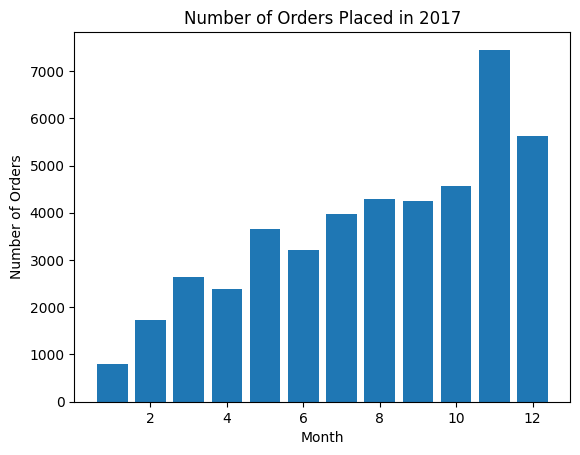

In [ ]:
orders_2017['month']= orders_2017['order_purchase_timestamp'].dt.month
monthly_orders = orders_2017.groupby('month')['order_id'].nunique()
plt.bar(monthly_orders.index, monthly_orders.values)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Number of Orders Placed in 2017')
plt.show()

### C. Find the total sales per category

In [ ]:
sales_per_category= df_merged.groupby('product_category')['price'].sum().reset_index()
sales_per_category= sales_per_category.sort_values(by='price', ascending=False)
sales_per_category

,product_category,price
30,HEALTH BEAUTY,1297490.77
45,Watches present,1253143.30
49,bed table bath,1092551.02
68,sport leisure,1023996.34
53,computer accessories,942277.57
...,...,...
58,flowers,1110.04
32,House Comfort 2,773.17
50,cds music dvds,730.00
18,Fashion Children's Clothing,569.85


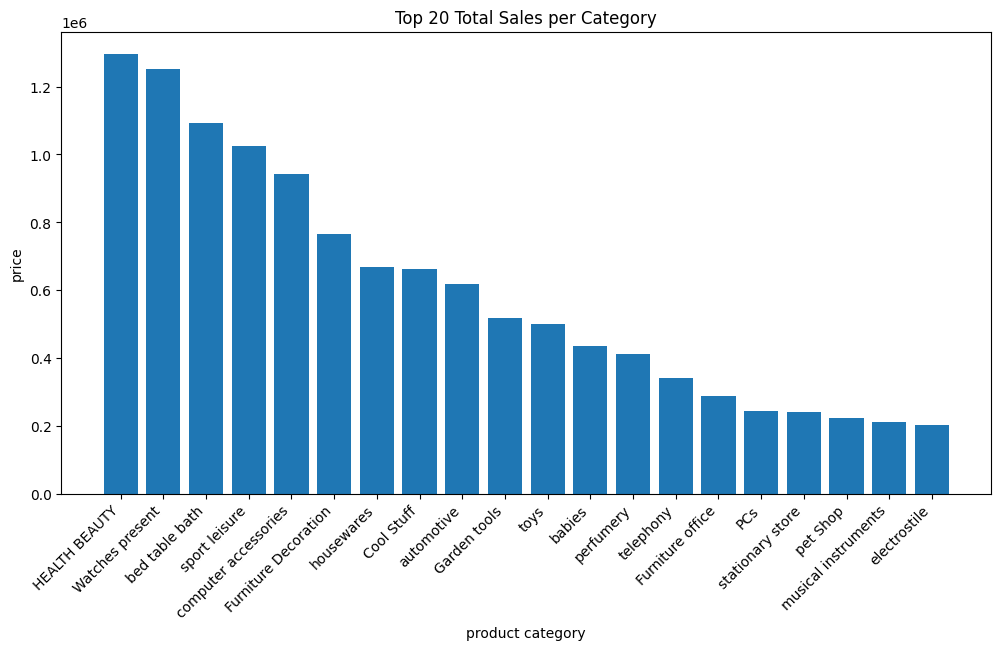

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(sales_per_category['product_category'].head(20), sales_per_category['price'].head(20))
plt.xlabel('product category')
plt.ylabel('price')
plt.title('Top 20 Total Sales per Category')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df_merged.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP


In [ ]:
df_merged.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category', 'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state'],
      dtype='object')

In [ ]:
df_merged['payment_installments'].unique()

array([ 1.,  3.,  6., 10.,  4.,  2.,  8.,  9.,  7.,  5., 13., 12., 15.,
       14., 21., 18., 24., 17., 11., 20., 23., 16., nan, 22.,  0.])

In [ ]:
payment_installments_counts = df_merged['payment_installments'].value_counts()
payment_installments_counts

,count
payment_installments,
1.0,59117
2.0,13794
3.0,11814
4.0,8027
10.0,6899
5.0,6056
8.0,5077
6.0,4638
7.0,1839


### D. Calculate the percentage of orders that were paid in installments

In [ ]:
#Total Number of Unique Orders
total_no_of_orders= df_merged['order_id'].nunique()
total_no_of_orders

#Total Number of Unique Orders paidin Installments
orders_installments= df_merged[df_merged['payment_installments'].notna()
& (df_merged['payment_installments'] > 1)]['order_id'].nunique()
orders_installments

#percentage of Orders that were paid in installments
percentage_installments= (orders_installments/total_no_of_orders)*100
percentage_installments= round(percentage_installments, 2)
percentage_installments


print("Total Number of Unique Orders Placed: ", total_no_of_orders)
print("Total Number of Unique Orders Paid in Installments: ", orders_installments)
print("Percentage of Orders Paid in Installments: ", percentage_installments,"%")

Total Number of Unique Orders Placed:  99441
Total Number of Unique Orders Paid in Installments:  51170
Percentage of Orders Paid in Installments:  51.46 %


### E. Count the number of customers from each state

In [ ]:
customer_state_counts= df_customers['customer_state'].value_counts().reset_index()
customer_state_counts

,customer_state,count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


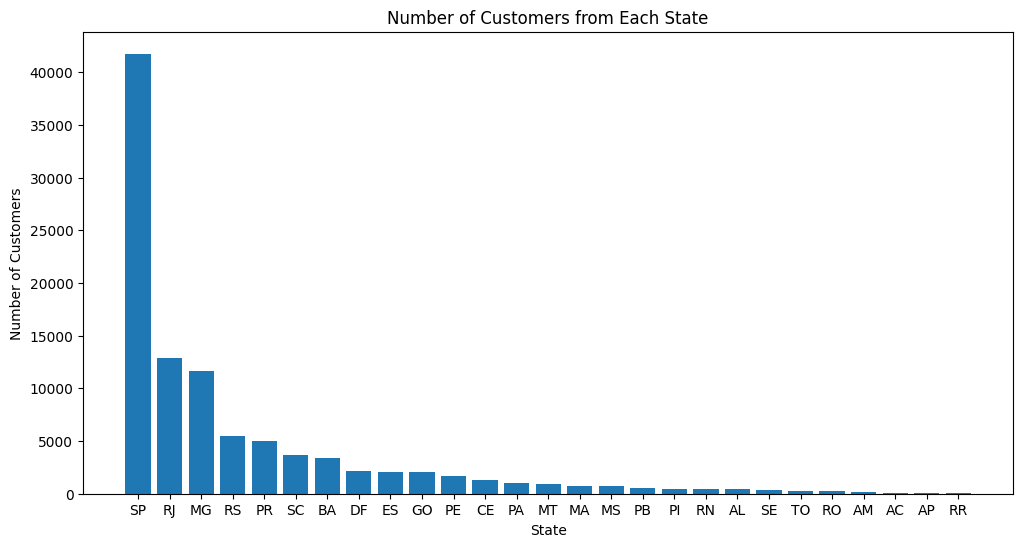

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(x=customer_state_counts['customer_state'], height=customer_state_counts['count'])
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Number of Customers from Each State')
plt.show()

# **2. INTERMEDIATE PROBLEMS:**

### A. Calculate the number of orders per month in 2018

In [7]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

In [8]:
orders_2018= df_orders[df_orders['order_purchase_timestamp'].dt.year== 2018]

order_count_2018= orders_2018.groupby(orders_2018['order_purchase_timestamp'].
                                      dt.month).size().reset_index(name='order_count')
order_count_2018

,order_purchase_timestamp,order_count
0,1,7269
1,2,6728
2,3,7211
3,4,6939
4,5,6873
5,6,6167
6,7,6292
7,8,6512
8,9,16
9,10,4


In [ ]:
orders_2018= df_merged[df_merged['order_purchase_timestamp'].dt.year== 2018]

order_count_2018= orders_2018.groupby(orders_2018['order_purchase_timestamp'].
                                      dt.month).size().reset_index(name='order_count')
order_count_2018

,order_purchase_timestamp,order_count
0,1,8597
1,2,7956
2,3,8567
3,4,8266
4,5,8248
5,6,7397
6,7,7351
7,8,7522
8,9,16
9,10,4


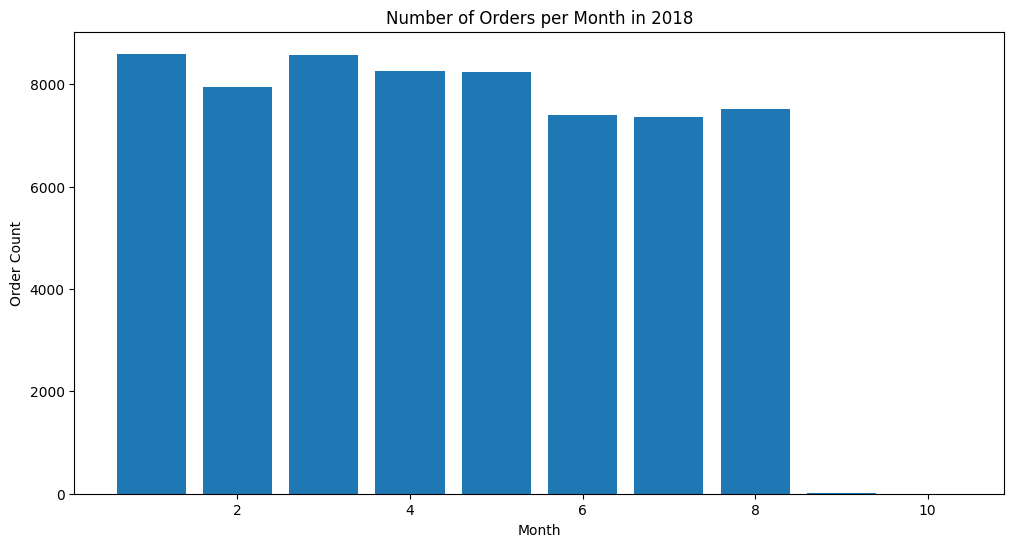

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(x=order_count_2018['order_purchase_timestamp'], height= order_count_2018['order_count'])
plt.xlabel('Month')
plt.ylabel('Order Count')
plt.title('Number of Orders per Month in 2018')
plt.show()

### B. Find the average number of products per order, grouped by customer city.

In [ ]:
avg_products_per_city= df_merged.groupby(['customer_city', 'order_id'])['product_id'].count().reset_index(name='avg_products_per_order_per_city' )


avg_products_per_city = avg_products_per_city.groupby('customer_city')['avg_products_per_order_per_city'].mean().reset_index()

avg_products_per_city = avg_products_per_city.sort_values(by='avg_products_per_order_per_city',
                                                          ascending=False)

print("Average number of products per order, grouped by customer city:")
avg_products_per_city



Average number of products per order, grouped by customer city:


,customer_city,avg_products_per_order_per_city
2625,padre carvalho,7.0
909,celso ramos,6.5
758,candido godoi,6.0
1156,datas,6.0
2269,matias olimpio,5.0
...,...,...
1949,jataizinho,0.0
1227,doutor mauricio cardoso,0.0
2383,monteiro lobato,0.0
640,caetanos,0.0


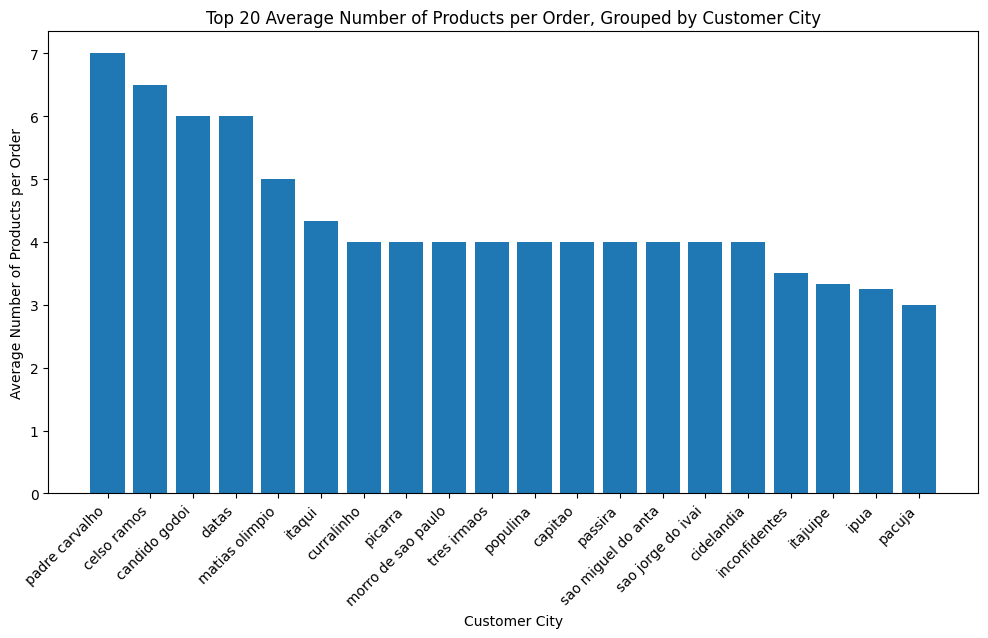

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(x=avg_products_per_city['customer_city'].head(20), height= avg_products_per_city['avg_products_per_order_per_city'].head(20))
plt.xlabel('Customer City')
plt.ylabel('Average Number of Products per Order')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Average Number of Products per Order, Grouped by Customer City')
plt.show()


### C. Calculate the percentage of total revenue contributed by each product category

In [12]:
rev_product_category= df_merged.groupby('product_category')['price'].sum().reset_index(name= 'revenue')
rev_product_category['product_category']= rev_product_category['product_category'].astype(str).str.lower().str.replace(' ', '_').str.strip()
rev_product_category

total_revenue= df_merged['price'].sum()

rev_product_category['percentage_revenue']= round((rev_product_category['revenue']/total_revenue)*100, 2)
rev_product_category= rev_product_category.sort_values(by='percentage_revenue', ascending=False).reset_index(drop=True)

rev_product_category



,product_category,revenue,percentage_revenue
0,health_beauty,1297490.77,9.13
1,watches_present,1253143.30,8.82
2,bed_table_bath,1092551.02,7.69
3,sport_leisure,1023996.34,7.21
4,computer_accessories,942277.57,6.63
...,...,...,...
68,house_comfort_2,773.17,0.01
69,flowers,1110.04,0.01
70,pc_gamer,1675.94,0.01
71,fashion_children's_clothing,569.85,0.00


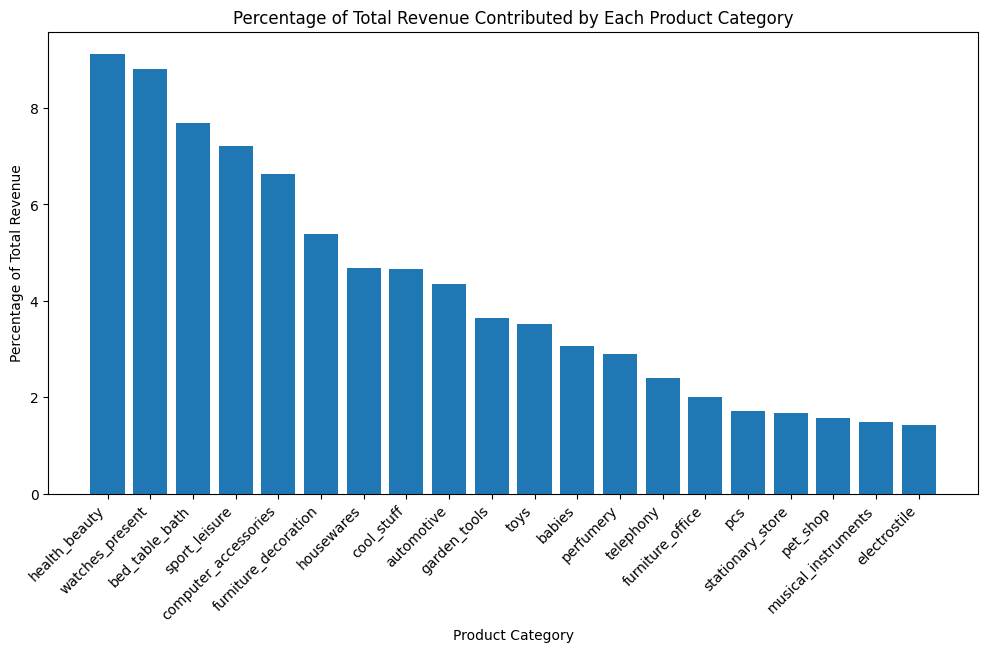

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(x=rev_product_category['product_category'].head(20), height= rev_product_category['percentage_revenue'].head(20))
plt.xlabel('Product Category')
plt.ylabel('Percentage of Total Revenue')
plt.title('Percentage of Total Revenue Contributed by Each Product Category')
plt.xticks(rotation=45, ha='right')
plt.show()

### D. Identify the correlation between product price and the number of times a product has been purchased

In [13]:
product_sales = (
    df_merged
    .groupby(['product_id', 'price'])
    .agg(purchase_count=('order_id', 'count'))
    .reset_index())

correlation = product_sales['price'].corr(product_sales['purchase_count'])
print(f"Correlation between product price and purchase count: {correlation}")

Correlation between product price and purchase count: -0.044187682605407216


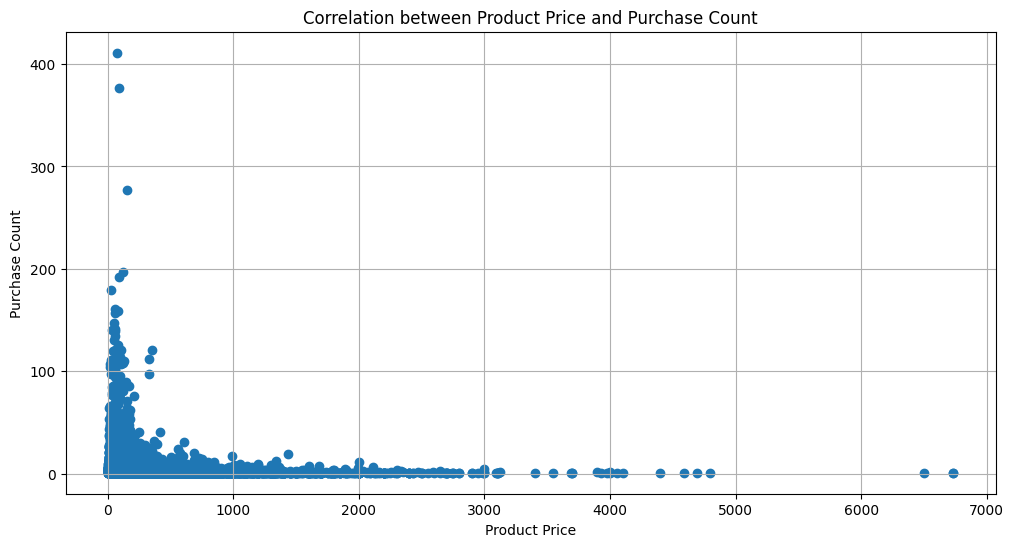

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(x=product_sales['price'], y=product_sales['purchase_count'])
plt.xlabel('Product Price')
plt.ylabel('Purchase Count')
plt.title('Correlation between Product Price and Purchase Count')
plt.grid(True)
plt.show()

### E. Calculate the total revenue generated by each seller, and rank them by revenue.

In [27]:
df_sellers_ranks = pd.merge(df_sellers, df_order_items, on='seller_id', how='inner')

In [29]:
seller_revenue_rank = df_sellers_ranks.groupby('seller_id')['price'].sum().reset_index(name='total_revenue')


seller_revenue_rank['rank'] = seller_revenue_rank['total_revenue'].rank(ascending=False).astype(int)
seller_revenue = seller_revenue_rank.sort_values(by='total_revenue', ascending=False)
seller_revenue

,seller_id,total_revenue,rank
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1
1013,53243585a1d6dc2643021fd1853d8905,222776.05,2
881,4a3ca9315b744ce9f8e9374361493884,200472.92,3
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,5
...,...,...,...
627,34aefe746cd81b7f3b23253ea28bef39,8.00,3091
1370,702835e4b785b67a084280efca355756,7.60,3092
373,1fa2d3def6adfa70e58c276bb64fe5bb,6.90,3093
1465,77128dec4bec4878c37ab7d6169d6f26,6.50,3094


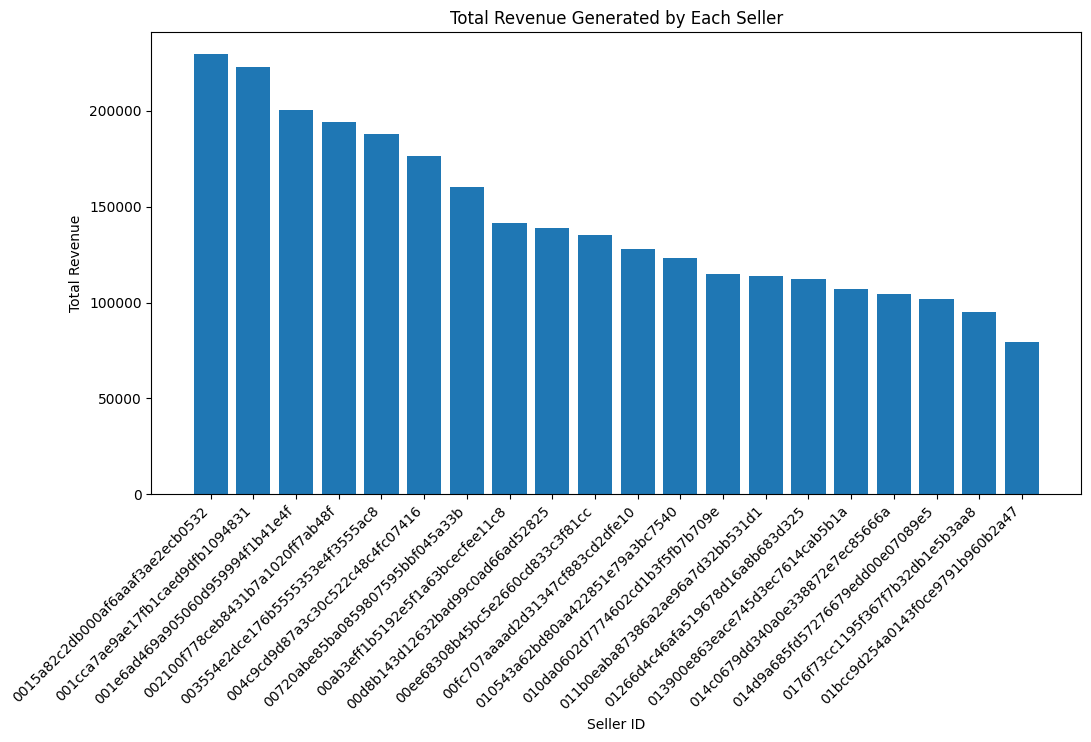

In [30]:
plt.figure(figsize=(12, 6))
plt.bar(x=seller_revenue_rank['seller_id'].head(20), height= seller_revenue['total_revenue'].head(20))
plt.xlabel('Seller ID')
plt.ylabel('Total Revenue')
plt.title('Total Revenue Generated by Each Seller')
plt.xticks(rotation=45, ha='right')
plt.show()

# **3. ADVANCED PROBLEMS:**

### A. Calculate the moving average of order values for each customer over their order history.

In [32]:
df = df_payments.merge(df_orders, on="order_id")

df = (
    df[["customer_id", "order_purchase_timestamp", "payment_value"]]
    .rename(columns={"payment_value": "payment"})
    .sort_values(["customer_id", "order_purchase_timestamp"])
)

df["mov_avg"] = (
    df.groupby("customer_id")["payment"]
      .rolling(window=3, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)
df

,customer_id,order_purchase_timestamp,payment,mov_avg
84862,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.74
70509,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.41
83602,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.42
90638,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.35
39592,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.01
...,...,...,...,...
102990,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.12
79218,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.13
31146,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.13
65622,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.50


### B. Calculate the cumulative sales per month for each year

In [34]:
df_cumm_sales = df_orders.merge(df_order_items, on="order_id")

df_cumm_sales["sales_year"] = df_cumm_sales["order_purchase_timestamp"].dt.year
df_cumm_sales["sales_month"] = df_cumm_sales["order_purchase_timestamp"].dt.month

monthly_sales = (
    df_cumm_sales.groupby(["sales_year", "sales_month"])["price"].sum().round(2) .reset_index(name="monthly_sales")
)

monthly_sales = monthly_sales.sort_values(["sales_year", "sales_month"])

monthly_sales["cumulative_sales"] = (
    monthly_sales.groupby("sales_year")["monthly_sales"].cumsum().round(2)
)

monthly_sales

,sales_year,sales_month,monthly_sales,cumulative_sales
0,2016,9,267.36,267.36
1,2016,10,49507.66,49775.02
2,2016,12,10.90,49785.92
3,2017,1,120312.87,120312.87
4,2017,2,247303.02,367615.89
5,2017,3,374344.30,741960.19
6,2017,4,359927.23,1101887.42
7,2017,5,506071.14,1607958.56
8,2017,6,433038.60,2040997.16
9,2017,7,498031.48,2539028.64


### C. Calculate the year-over-year growth rate of total sales

In [ ]:
yearly_sales = df_merged.groupby('order_year')['price'].sum().reset_index()
yearly_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# Calculate Year-over-Year Growth Rate
yearly_sales['previous_year_sales'] = yearly_sales['total_sales'].shift(1)

yearly_sales['yoy_growth_rate'] = ((yearly_sales['total_sales'] - yearly_sales['previous_year_sales'])
 / yearly_sales['previous_year_sales']) * 100

yearly_sales['yoy_growth_rate'] = yearly_sales['yoy_growth_rate'].fillna(0)

print("Year-over-Year Growth Rate of Total Sales:")
display(yearly_sales)

Year-over-Year Growth Rate of Total Sales:


,order_year,total_sales,previous_year_sales,yoy_growth_rate
0,2016,51220.49,NaN,0.000000
1,2017,6483893.86,51220.49,12558.789207
2,2018,7674135.96,6483893.86,18.356903


### D. Identify the top 3 customers who spent the most money in each year.

In [37]:
df_top_3_cust = df_orders.merge(df_order_items, on="order_id")
df_top_3_cust["sales_year"] = df_top_3_cust["order_purchase_timestamp"].dt.year

customer_yearly_spend = (df_top_3_cust.groupby(["sales_year", "customer_id"])["price"].sum()
      .round(2)
      .reset_index(name="total_spent"))

customer_yearly_spend["spend_rank"] = (customer_yearly_spend
    .groupby("sales_year")["total_spent"]
    .rank(method="dense", ascending=False))

top_customers = (customer_yearly_spend[customer_yearly_spend["spend_rank"] <= 3]
    .sort_values(["sales_year", "spend_rank"]))

top_customers


,sales_year,customer_id,total_spent,spend_rank
213,2016,a9dc96b027d1252bbac0a9b72d837fc6,1399.00,1.0
37,2016,1d34ed25963d5aae4cf3d7f3a4cda173,1299.99,2.0
80,2016,4a06381959b6670756de02e07b83815f,1199.00,3.0
4156,2017,1617b1357756262bfa56ab541c47bc16,13440.00,1.0
35059,2017,c6e2731c5b391845f6800c97401a43a9,6735.00,2.0
11418,2017,3fd6777bbce08a352fddd04e4a7cc8f6,6499.00,3.0
94592,2018,ec5b2ba62e574342386871631fafd3fc,7160.00,1.0
96320,2018,f48d464a0baaea338cb25f816991ab1f,6729.00,2.0
92125,2018,e0a2412720e9ea4f26c1ac985f6a7358,4599.90,3.0
